In [11]:
# TO INSPECT THE STRUCTURE OF YOUR NETCDF FILE RUN THE FOLLOWING WITH THE CORRECT FILE PATH
# 
!ncdump -h S6A_P4_2__LR_STD__NT_035_126_20211025T162800_20211025T172413_G01.nc

netcdf S6A_P4_2__LR_STD__NT_035_126_20211025T162800_20211025T172413_G01 {

// global attributes:
		:Convention = "CF-1.7" ;
		:institution = "EUMETSAT" ;
		:references = "Sentinel-6_Jason-CS ALT Generic Product Format Specification (897975 v6), Sentinel-6_Jason-CS ALT Level 2 Product Format Specification (901187 v5A), Sentinel-6_Jason-CS ALT Level 2 NetCDF Dump (957846 v6)" ;
		:contact = "ops@eumetsat.int" ;
		:radiometer_sensor_name = "AMR-C" ;
		:doris_sensor_name = "DORIS" ;
		:gnss_sensor_name = "GNSS" ;
		:title = "L2 LR Non Time Critical" ;
		:source = "Processing Baseline G01" ;
		:history = "2025-05-30 22:16:27 : Creation" ;
		:mission_name = "Sentinel-6A" ;
		:altimeter_sensor_name = "Poseidon-4B" ;
		:acq_station_name = "Fairbanks" ;
		:netcdf_version = "4.7.0 of Jul 16 2023 05:24:29 $" ;
		:cycle_number = 35 ;
		:pass_number = 126 ;
		:absolute_rev_number = 4330 ;
		:first_measurement_time = "2021-10-25T16:28:00.548154Z" ;
		:last_measurement_time = "2021-10-25T17:24:13.498

In [12]:
##Load netCDF file and read the variables of intereset based on the nested groups and subgroups structure

from netCDF4 import Dataset

file_path = "S6A_P4_2__LR_STD__NT_035_126_20211025T162800_20211025T172413_G01.nc"

# Open the file using the netCDF4 library
try:
    with Dataset(file_path, "r") as ds:
        # Navigate the groups
        grp = ds.groups["data_01"]

        # Pull latitude/longitude from the 'data_01' group 
        lat = grp.variables["latitude"][:]
        lon = grp.variables["longitude"][:]

        open_ocean_flag = grp.variables["surface_classification_flag"][:]
        open_ocean = (open_ocean_flag == 0)

        #Filter data to keep only the one in the open ocean
        lat_keep = lat[open_ocean]
        lon_keep = lon[open_ocean]
        
        print("Success! Data loaded.")        
except Exception as e:
    print(f"Error processing file {file_path}: {e}")

Success! Data loaded.


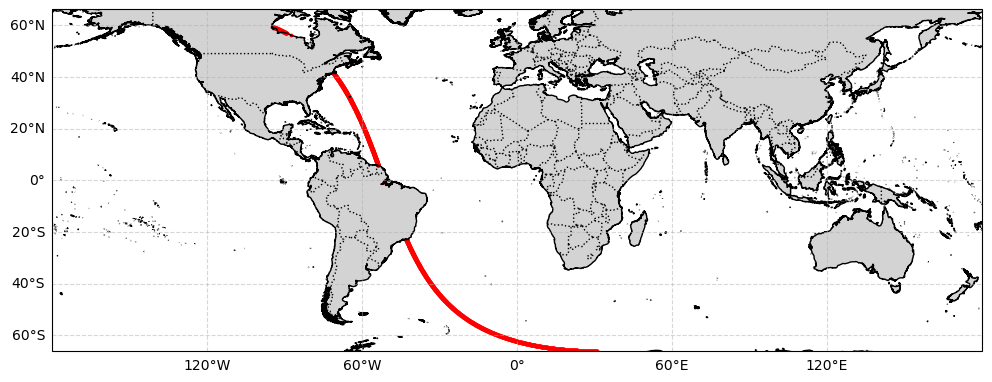

In [13]:
### Plot the extracted data

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
    
ax.set_extent([min(lon), max(lon), min(lat), max(lat)], crs=ccrs.PlateCarree())
    
# Add geographical references
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':')
    
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.scatter(lon_keep, lat_keep, color="red", s=3, transform=ccrs.PlateCarree(), label="Dati Sentinel-6")
plt.show()

Success! Data loaded.


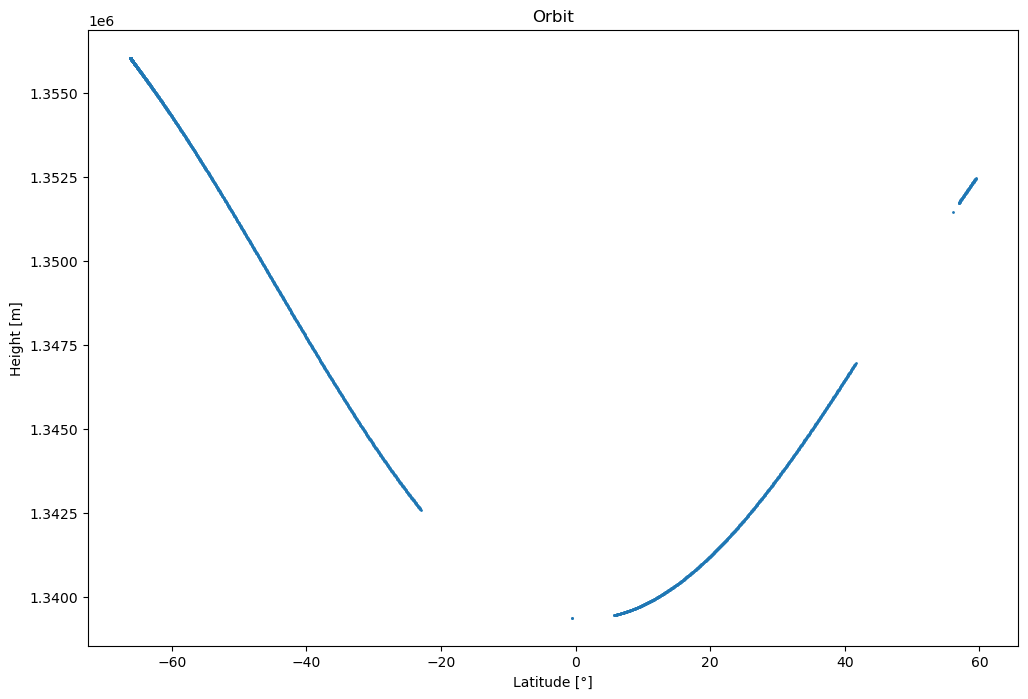

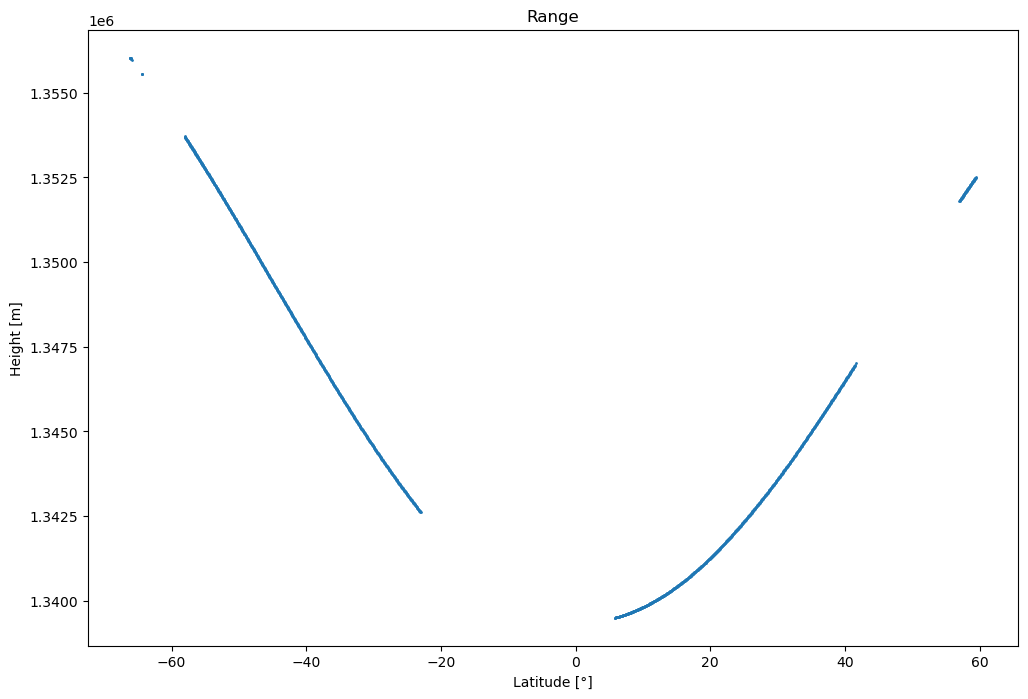

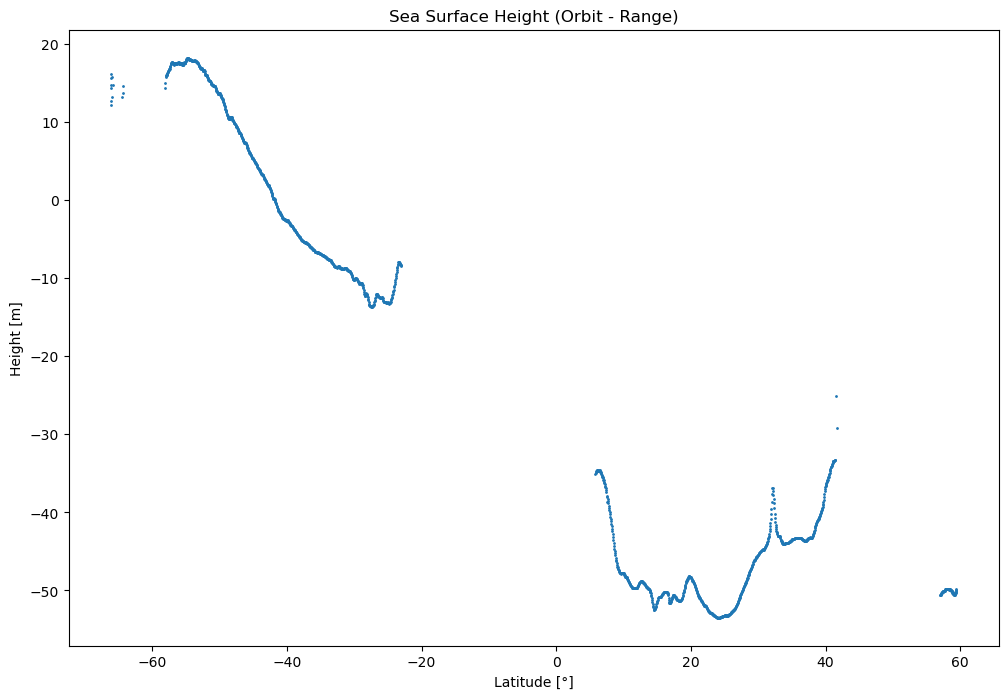

In [16]:
### Proceed in the same way with the others variables of interest
from netCDF4 import Dataset
import matplotlib.pyplot as plt

### RANGE ###
try:
    with Dataset(file_path, "r") as ds:
        # Navigate the groups
        grp = ds.groups["data_01"]
        sub_grp = grp.groups["ku"]

        # Pull latitude/longitude from the 'data_01' group 
        lat = grp.variables["latitude"][:]
        orbit = grp.variables["altitude"][:]
        range = sub_grp.variables["range_ocean"][:]

        open_ocean_flag = grp.variables["surface_classification_flag"][:]
        open_ocean = (open_ocean_flag == 0)

        #Filter data to keep only the one in the open ocean
        lat_keep = lat[open_ocean]
        orbit_keep = orbit[open_ocean]
        range_keep = range[open_ocean]
        
        print("Success! Data loaded.")        
except Exception as e:
    print(f"Error processing file {file_path}: {e}")

#Plot Orbit

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_keep, orbit_keep, s=1)
plt.title("Orbit")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Range

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_keep, range_keep, s=1)
plt.title("Range")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

sea_surface_height = orbit_keep - range_keep 

#Plot Sea Surface Height
fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_keep, sea_surface_height, s=1)
plt.title("Sea Surface Height (Orbit - Range)")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

Success! Data loaded.


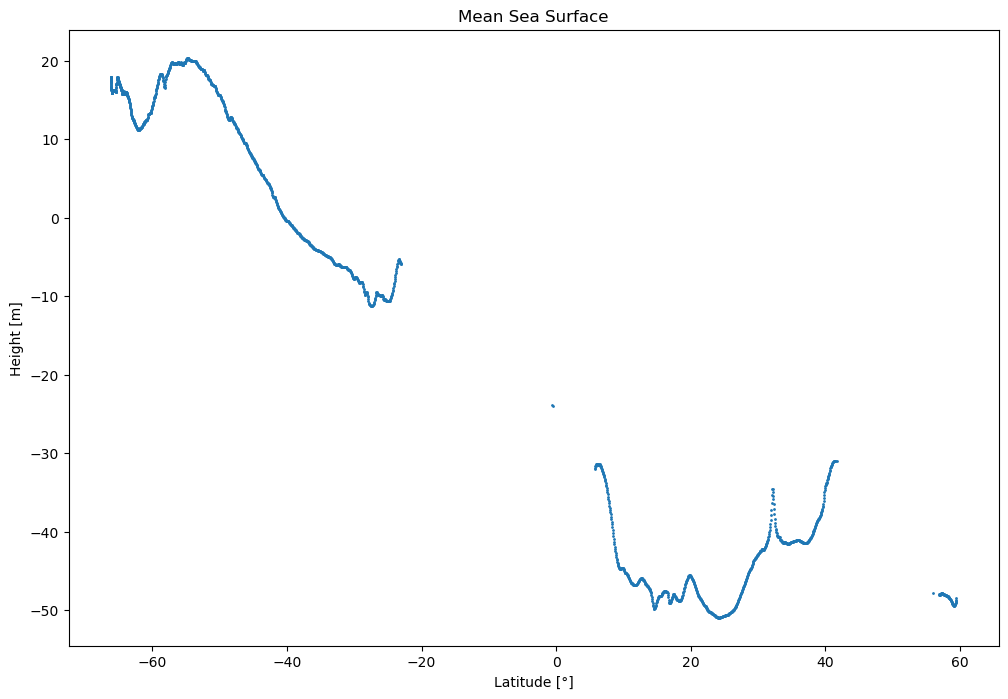

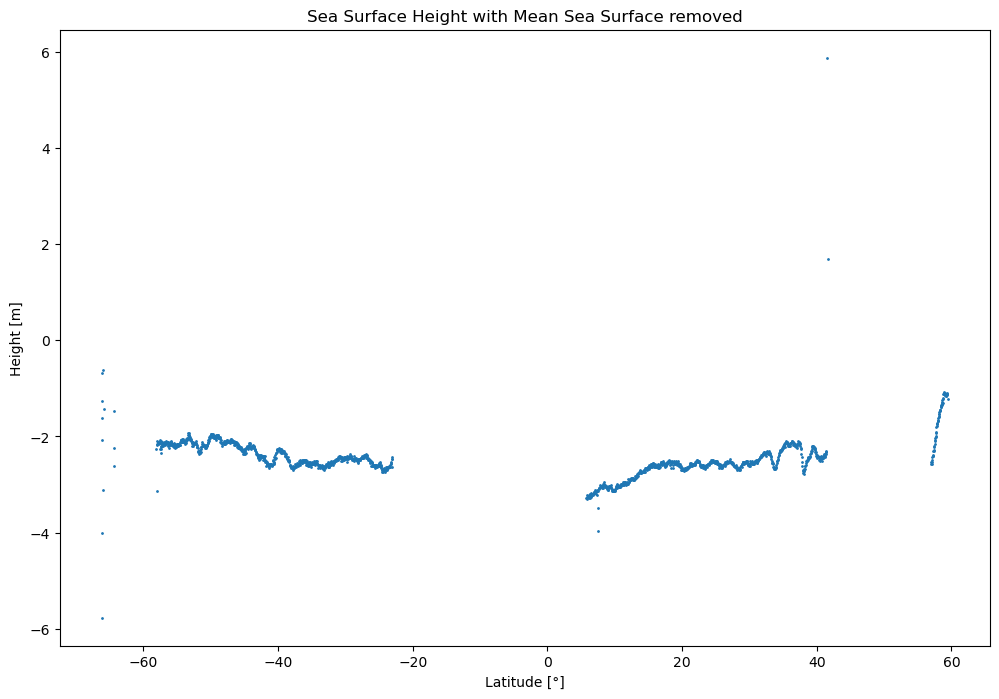

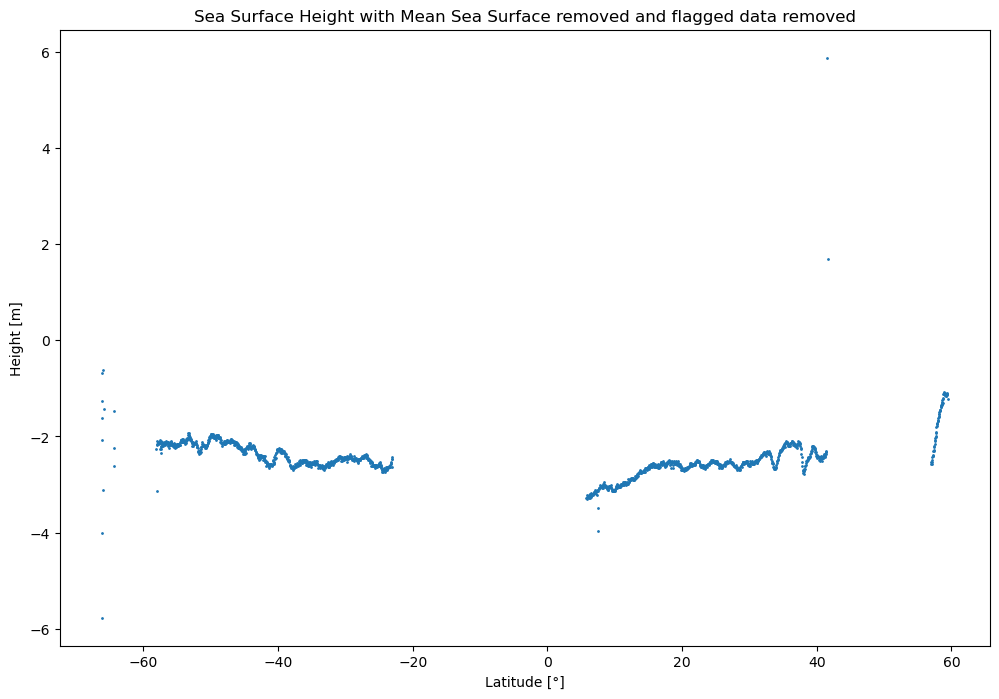

In [ ]:
### Proceed in the same way with the others variables of interest
from netCDF4 import Dataset
import matplotlib.pyplot as plt

### vARIABLES EXTRACTION ###
try:
    with Dataset(file_path, "r") as ds:
        # Navigate the groups
        grp = ds.groups["data_01"]
        sub_grp = grp.groups["ku"]

        # Pull latitude/longitude from the 'data_01' group 
        lat = grp.variables["latitude"][:]
        mean_sea_surface = grp.variables["mean_sea_surface_sol1"][:]
        qual_flag = grp.variables["mean_sea_surface_sol1_qual"][:]

        open_ocean_flag = grp.variables["surface_classification_flag"][:]
        open_ocean = (open_ocean_flag == 0)

        #Filter data to keep only the one in the open ocean
        lat_raw = lat[open_ocean]
        mss_raw = mean_sea_surface[open_ocean]
        qual_flag_raw = qual_flag[open_ocean]
        
        print("Success! Data loaded.")        
except Exception as e:
    print(f"Error processing file {file_path}: {e}")

#Plot Mean Sea Surface

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_raw, mss_raw, s=1)
plt.title("Mean Sea Surface")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height with Mean Sea Surface removed
new_ssh = sea_surface_height - mss_raw
fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_raw, (new_ssh), s=1)
plt.title("Sea Surface Height with Mean Sea Surface removed")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height with Mean Sea Surface removed and flagged data removed
quality_flag = (qual_flag_raw == 0)
lat_keep = lat_raw[quality_flag]
new_ssh_1 = new_ssh[quality_flag]

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat_keep, new_ssh_1, s=1)
plt.title("Sea Surface Height with Mean Sea Surface removed and flagged data removed")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()


In [ ]:
### Same extraction procedure for: ionospheric correction, dry tropospheric correction, 
# wet tropospheric correction, tidal correction, sea state bias correction, 
# dynamic atmospheric correction (DAC)


from netCDF4 import Dataset
import matplotlib.pyplot as plt

### VARIABLES EXTRACTION ###
try:
    with Dataset(file_path, "r") as ds:
        # Navigate the groups
        grp = ds.groups["data_01"]
        sub_grp = grp.groups["ku"]

        # Pull latitude/longitude from the 'data_01' group 
        lat_raw = grp.variables["latitude"][:]

        iono_corr_raw = grp.variables["iono_cor_alt"][:]

        dry_trop_corr_raw = grp.variables["model_dry_tropo_cor_measurement_altitude"][:]

        wet_trop_corr_radiometer_raw = grp.variables["amr_wet_tropo_cor"][:]
        wet_trop_corr_model_raw = grp.variables["model_wet_tropo_cor_measurement_altitude"][:]

        tidal_corr_GOT410_raw = grp.variables["ocean_tide_sol1"][:]
        tidal_corr_FES2022b_raw = grp.variables["ocean_tide_sol2"][:]

        ssb_corr_raw = sub_grp.variables["sea_state_bias"][:]

        dac_corr_raw = grp.variables["dac"][:]

        open_ocean_flag = grp.variables["surface_classification_flag"][:]
        open_ocean = (open_ocean_flag == 0)

        #Filter data to keep only the one in the open ocean
        lat = lat_raw[open_ocean]
        iono_corr = iono_corr_raw[open_ocean]
        dry_trop_corr = dry_trop_corr_raw[open_ocean]
        wet_trop_corr_radiometer = wet_trop_corr_radiometer_raw[open_ocean]
        wet_trop_corr_model = wet_trop_corr_model_raw[open_ocean]
        tidal_corr_GOT410 = tidal_corr_GOT410_raw[open_ocean]
        tidal_corr_FES2022b = tidal_corr_FES2022b_raw[open_ocean]
        ssb_corr = ssb_corr_raw[open_ocean]
        dac_corr = dac_corr_raw[open_ocean]

        print("Success! Data loaded.")        
except Exception as e:
    print(f"Error processing file {file_path}: {e}")


Success! Data loaded.


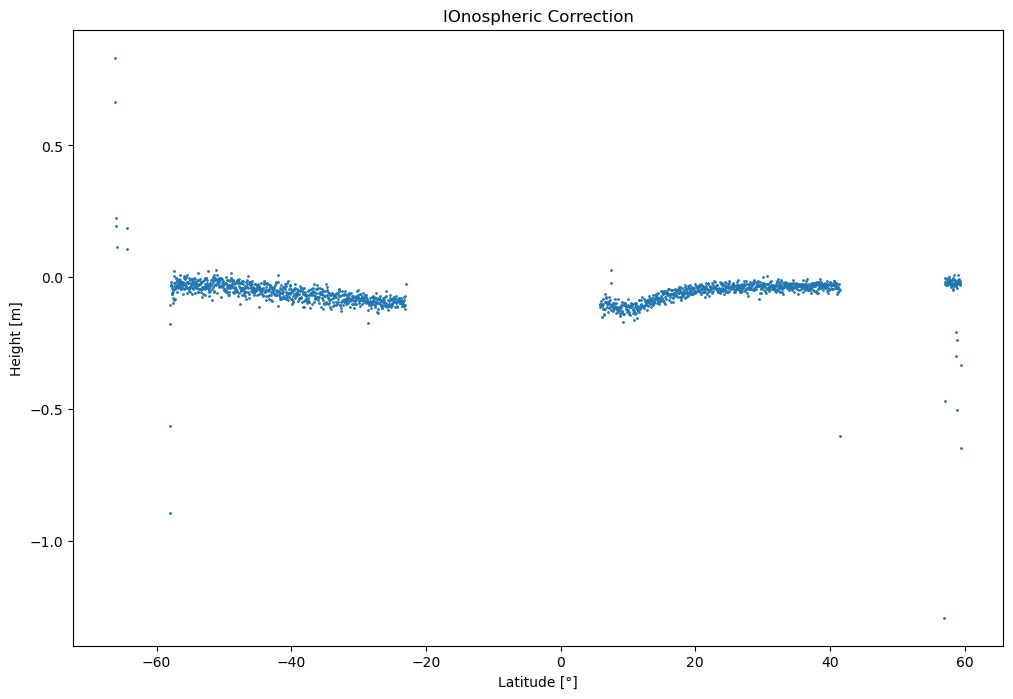

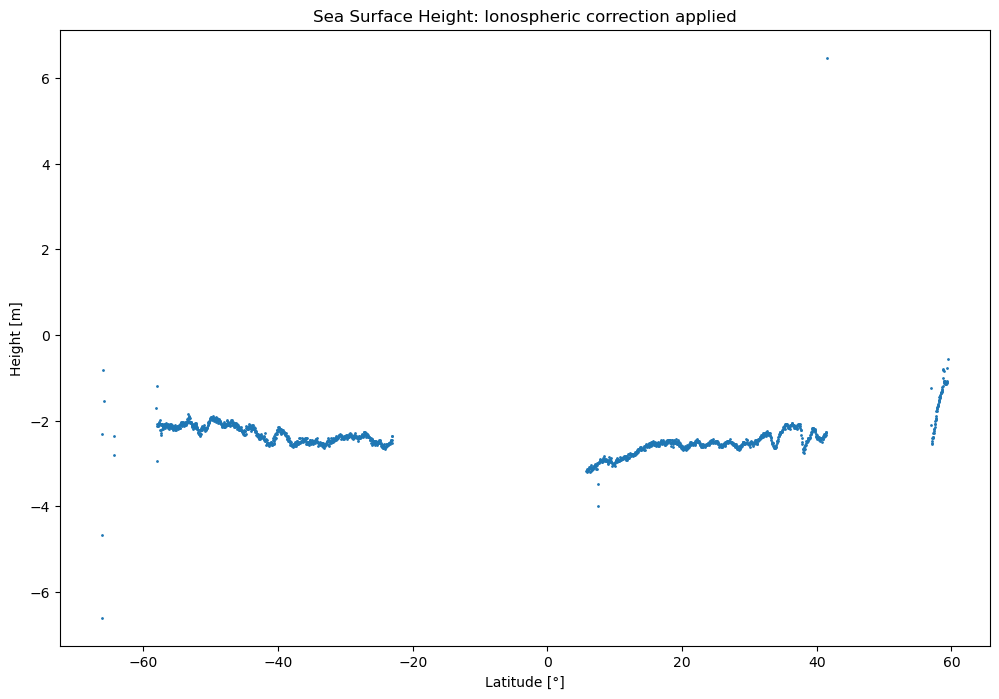

In [ ]:
#Plot Ionospheric Correction

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, iono_corr, s=1)
plt.title("Ionospheric Correction")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: Ionospheric correction applied
new_ssh_2 = new_ssh - iono_corr
fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, new_ssh_2, s=1)
plt.title("Sea Surface Height: Ionospheric correction applied")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

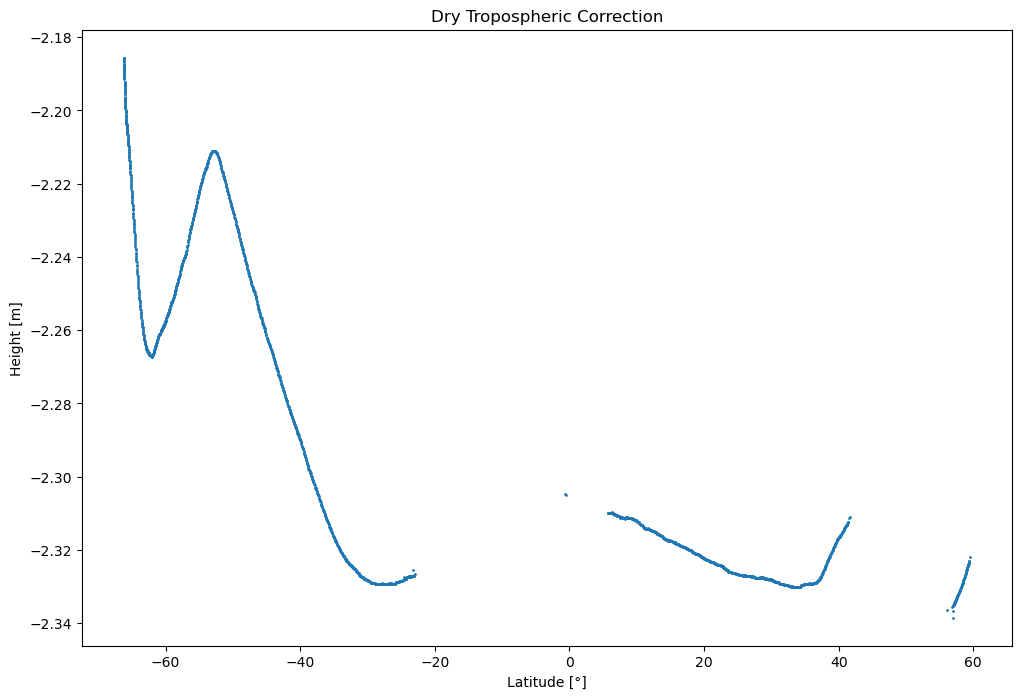

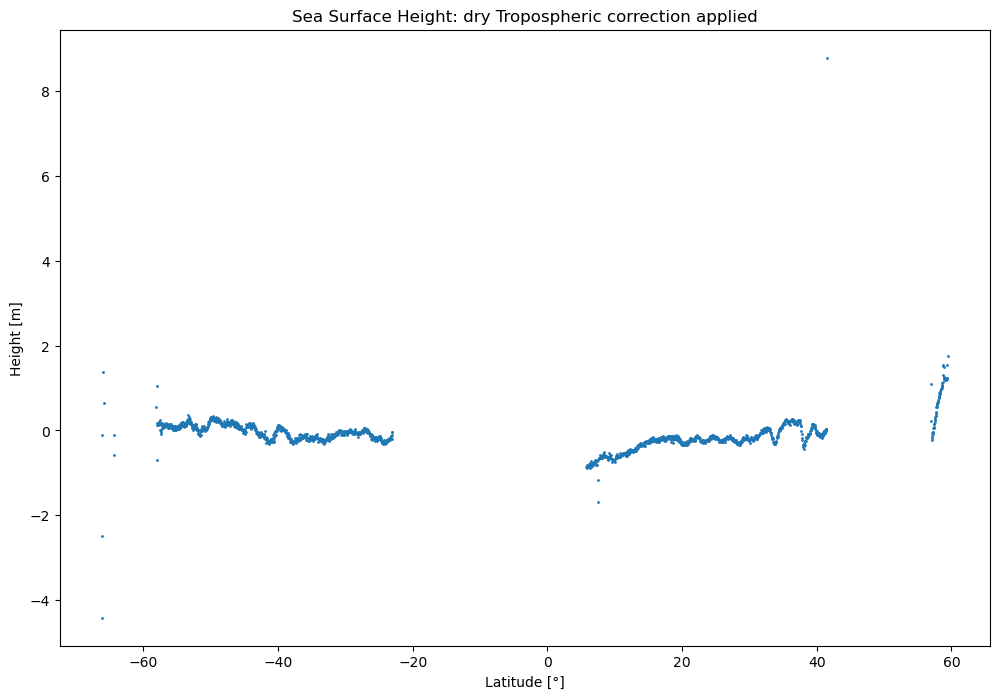

In [ ]:
#Plot Plot dry Tropospheric Correction

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, dry_trop_corr, s=1)
plt.title("Dry Tropospheric Correction")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: dry Tropospheric correction applied
new_ssh_3 = new_ssh_2 - dry_trop_corr

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, new_ssh_3, s=1)
plt.title("Sea Surface Height: dry Tropospheric correction applied")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

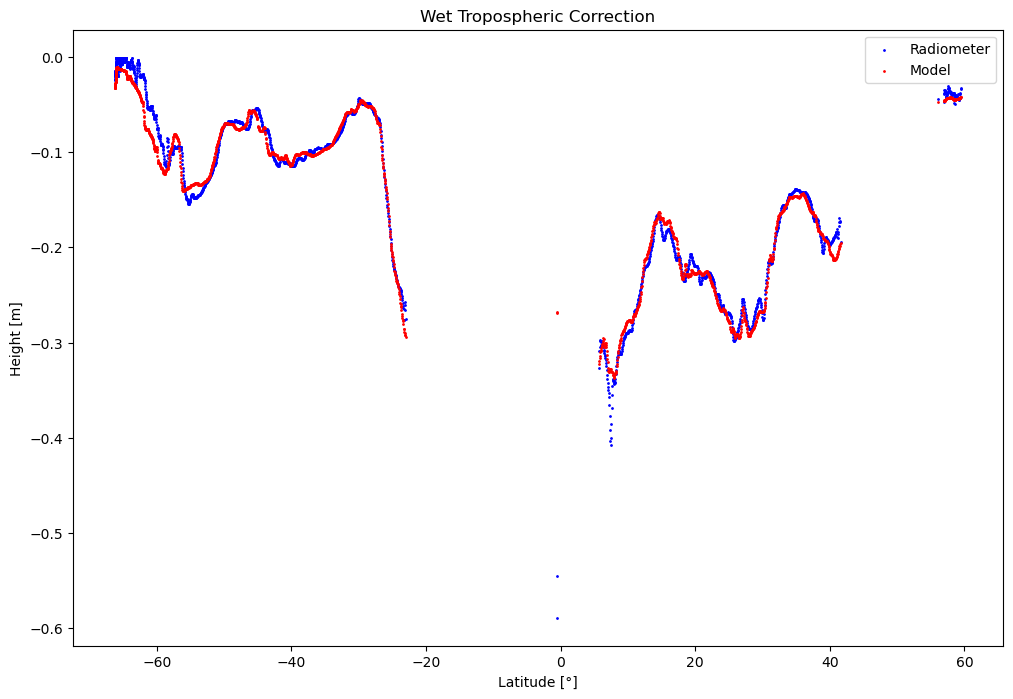

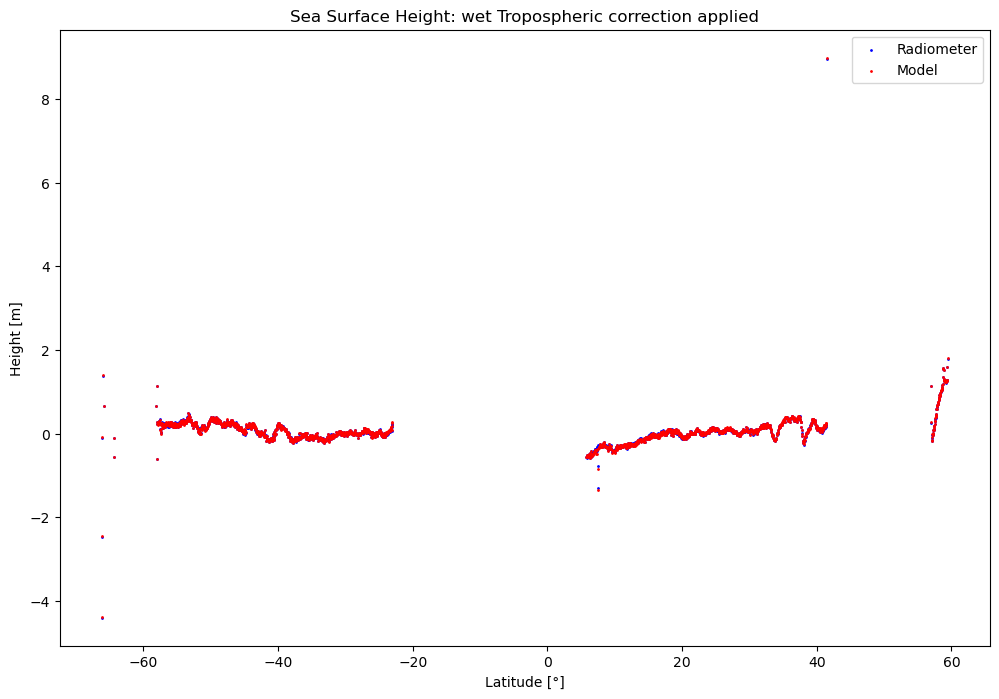

In [27]:
#Plot Plot wet Tropospheric Correction

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, wet_trop_corr_radiometer, s=1, color='blue', label="Radiometer")
plt.scatter(lat, wet_trop_corr_model, s=1, color='red', label="Model")
plt.title("Wet Tropospheric Correction")
plt.legend()
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: wet Tropospheric correction applied
new_ssh_4 = new_ssh_3 - wet_trop_corr_radiometer
new_ssh_5 = new_ssh_3 - wet_trop_corr_model

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, new_ssh_4, s=1, color='blue', label="Radiometer")
plt.scatter(lat, new_ssh_5, s=1, color='red', label="Model")
plt.title("Sea Surface Height: wet Tropospheric correction applied")
plt.legend()
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

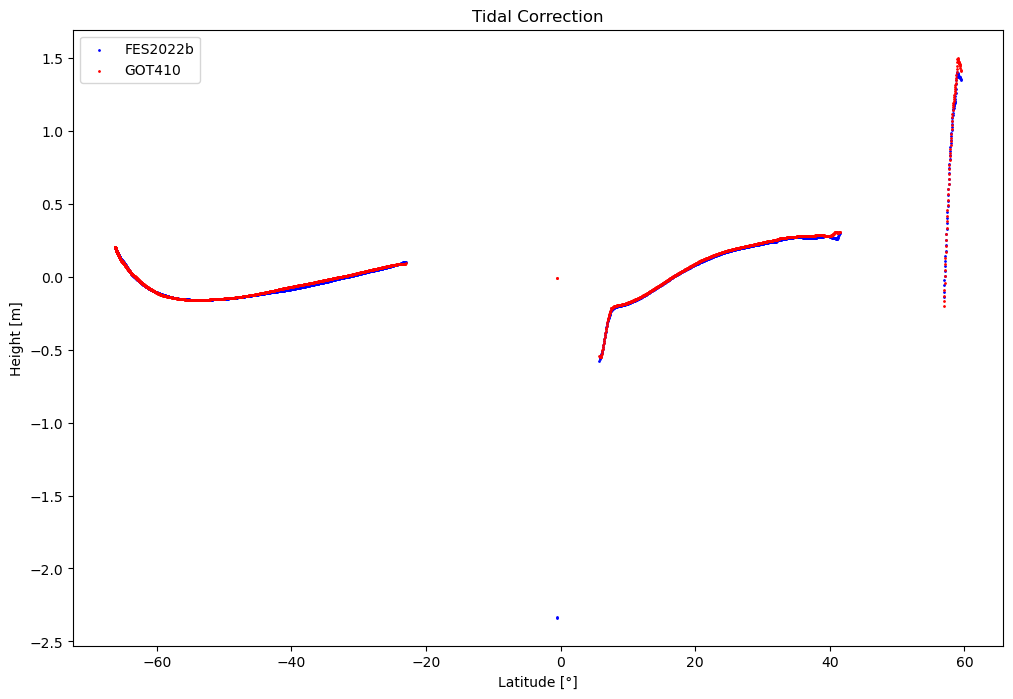

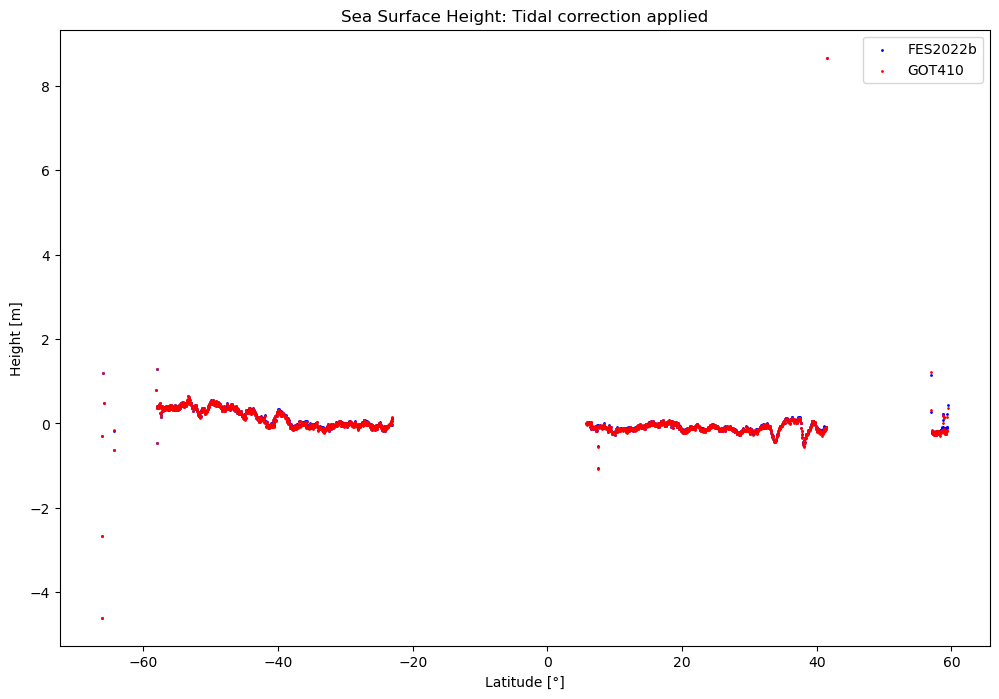

In [28]:
#Plot Plot Tidal Correction

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, tidal_corr_FES2022b, s=1, color='blue', label="FES2022b")
plt.scatter(lat, tidal_corr_GOT410, s=1, color='red', label="GOT410")
plt.title("Tidal Correction")
plt.legend()
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: Tidal correction applied
new_ssh_6 = new_ssh_4 - tidal_corr_FES2022b
new_ssh_7 = new_ssh_4 - tidal_corr_GOT410

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, new_ssh_6, s=1, color='blue', label="FES2022b")
plt.scatter(lat, new_ssh_7, s=1, color='red', label="GOT410")
plt.title("Sea Surface Height: Tidal correction applied")
plt.legend()
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

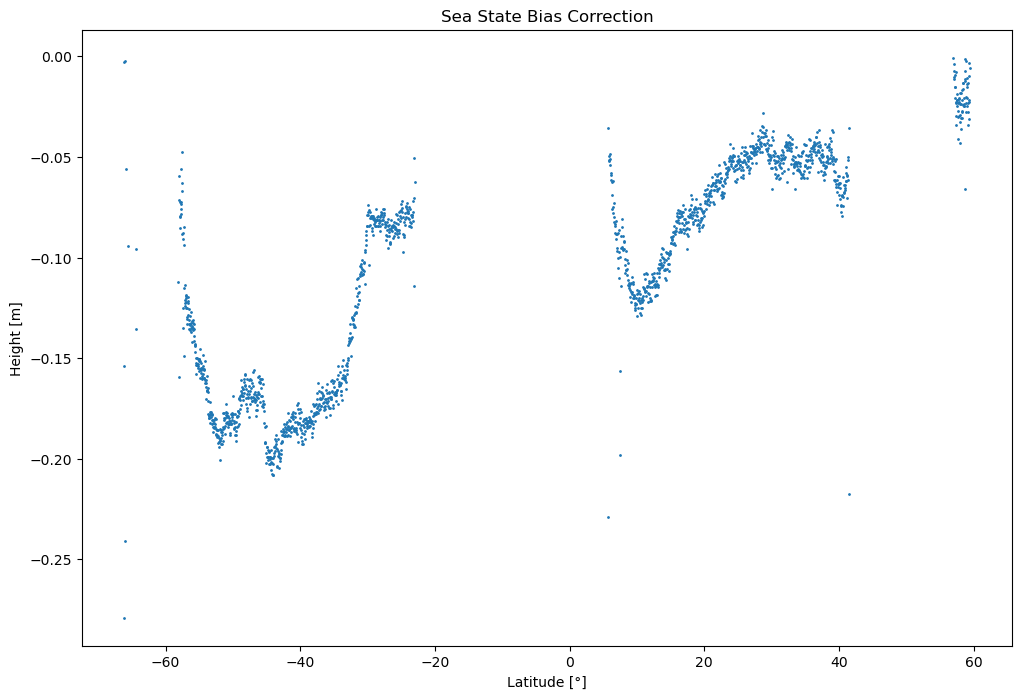

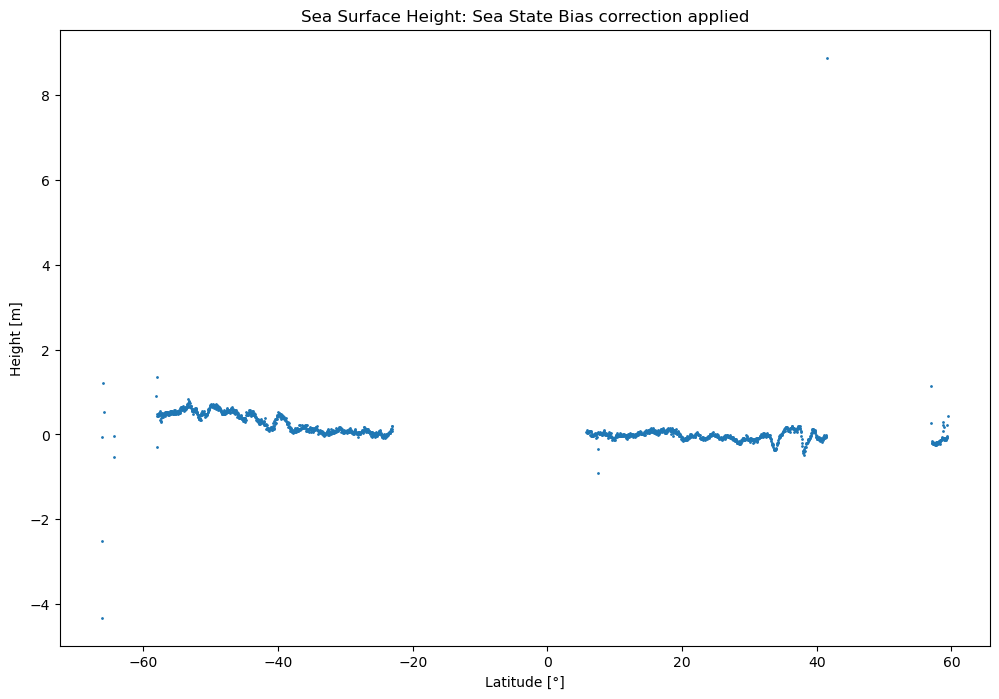

In [29]:
#Plot Plot Sea State Bias Correction

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, ssb_corr, s=1)
plt.title("Sea State Bias Correction")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: Sea State Bias correction applied
new_ssh_8 = new_ssh_6 - ssb_corr

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, new_ssh_8, s=1)
plt.title("Sea Surface Height: Sea State Bias correction applied")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

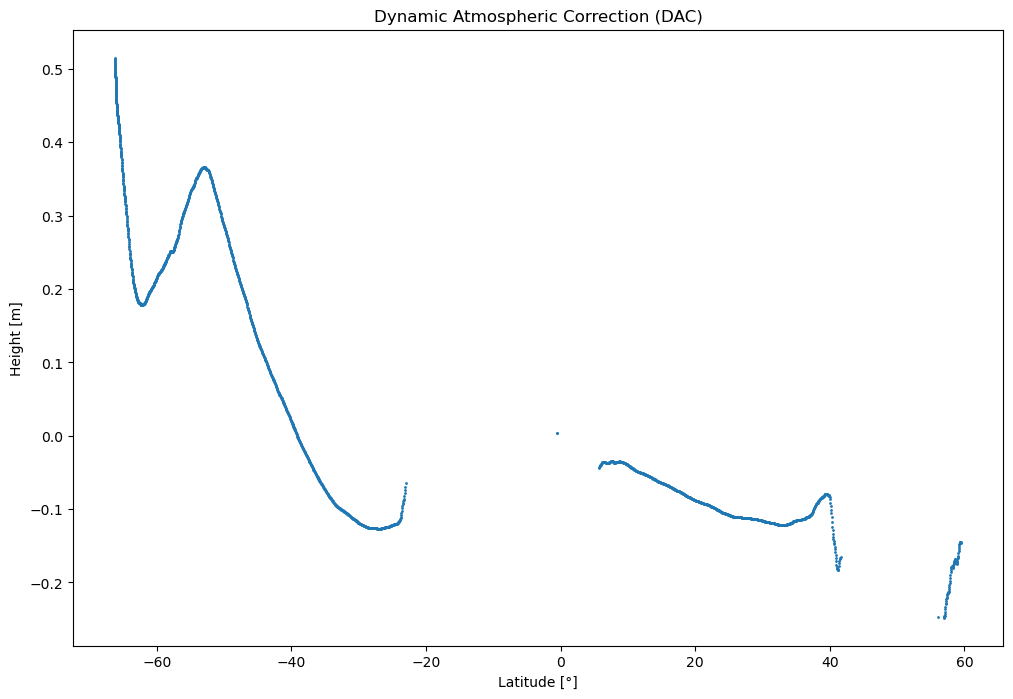

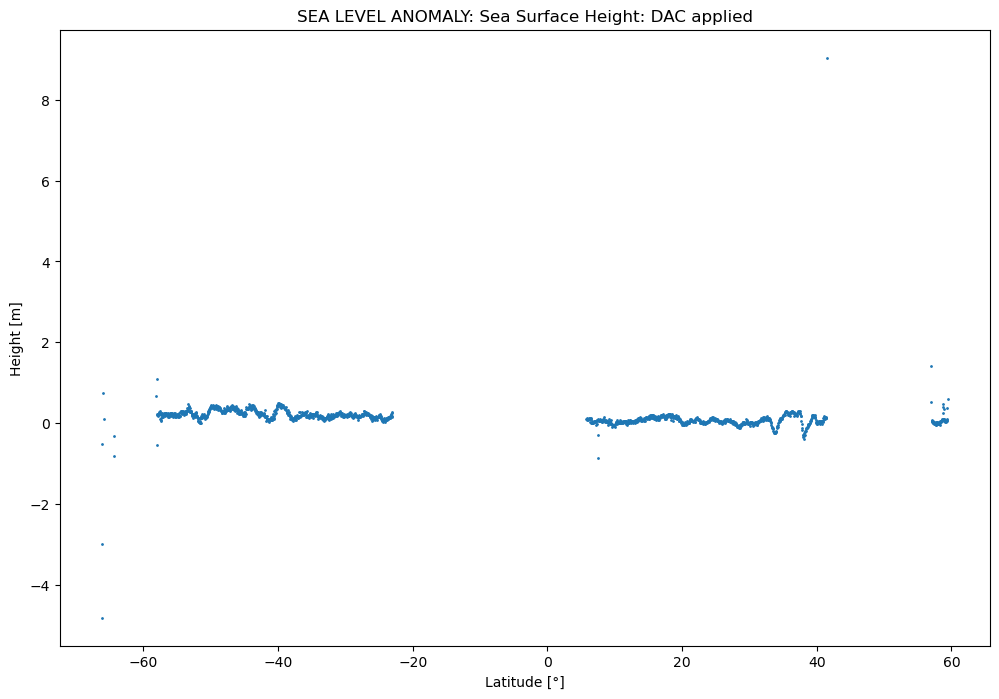

In [30]:
#Plot Plot Dynamic Atmospheric Correction (DAC)

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, dac_corr, s=1)
plt.title("Dynamic Atmospheric Correction (DAC)")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()

#Plot Sea Surface Height: Dynamic Atmospheric Correction (DAC) applied
sla = new_ssh_8 - dac_corr  # Sea Level Anomaly = ALTITUDE - RANGE - MEAN SEA SURFACE - CORRECTIONS

fig = plt.figure(figsize=(12, 8))
plt.scatter(lat, sla, s=1)
plt.title("SEA LEVEL ANOMALY: Sea Surface Height: DAC applied")
plt.xlabel("Latitude [°]")
plt.ylabel("Height [m]")
plt.show()